# # **Project Name**    - Ford GoBike Trip Analysis

##### **Project Type**    - Data Understanding, cleaning and EDA
##### **Contribution**    - Individual

## 📑 Table of Contents 

1. Project Summary

2. Import Libraries

3. Data Import

4. Data Understanding

5. Data Cleaning

6. Feature Engineering

7. Final Data Validation

8. Exploratory Data Analysis (EDA)

9. Business Recommendations


# **Project Summary -**

The Ford GoBike Sharing Data Analysis project aims to analyze one year of bike-sharing trip data to uncover customer travel patterns, station usage, and operational trends. The dataset consists of monthly trip records from January to December 2018, containing information about trip duration, start and end stations, bike IDs, user demographics, and subscription types.

The project begins with consolidating the 12 monthly datasets into a single dataset, followed by comprehensive data cleaning to ensure data quality and consistency. After cleaning, extensive Exploratory Data Analysis (EDA) is performed to identify patterns in ride demand, customer behavior, peak usage hours, demographic trends, station popularity, and trip characteristics.

Through statistical analysis and visualizations, the project provides actionable insights that can help optimize bike distribution, improve station management, enhance customer experience, and support data-driven business decisions for the bike-sharing service.

# ***Let's Begin !***

## ***1. Know Your Data***

# ============================================
# Import Required Libraries
# ============================================

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

============================================
##  Notebook Configuration
 ============================================

### Configuring the Notebook

Before loading the dataset, we'll configure the notebook for better readability.

These settings improve how dataframes are displayed, apply a consistent visualization style, and suppress unnecessary warnings.

In [2]:

# Ignore warning messages
warnings.filterwarnings("ignore")

# Display all columns in a dataframe
pd.set_option("display.max_columns", None)

# Display up to 100 rows when printing dataframes
pd.set_option("display.max_rows", 100)

# Set a clean plotting style
plt.style.use("ggplot")

# Set Seaborn theme
sns.set_theme(style="whitegrid")

# Importing the Dataset

The dataset for this project is provided as 12 separate CSV files, with each file representing one month of Ford GoBike trip data for the year 2018.

Instead of loading each file individually, we will use Python's `glob` module to automatically locate all CSV files in the dataset folder. This approach makes the code more efficient, organized, and easier to maintain, especially when working with multiple files.

After locating all the files, they will be merged into a single DataFrame, creating one complete dataset for further analysis.

In [3]:
# ============================================
# Import Modules for File Handling
# ============================================

# OS module helps interact with the operating system.
# It is useful for working with file and folder paths.
import os

# Glob module is used to locate all files matching
# a specific pattern (e.g., all CSV files in a folder).
import glob

In [4]:
# ============================================
# Locate All CSV Files
# ============================================

# Search for every CSV file inside the dataset folder.
csv_files = glob.glob("Dataset/*.csv")

# Display the total number of files found.
print(f"Total CSV Files Found: {len(csv_files)}")

Total CSV Files Found: 12


In [5]:
# ============================================
# Display All File Names
# ============================================

for file in csv_files:
    print(os.path.basename(file))

201801-fordgobike-tripdata.csv
201802-fordgobike-tripdata.csv
201803-fordgobike-tripdata.csv
201804-fordgobike-tripdata.csv
201805-fordgobike-tripdata.csv
201806-fordgobike-tripdata.csv
201807-fordgobike-tripdata.csv
201808-fordgobike-tripdata.csv
201809-fordgobike-tripdata.csv
201810-fordgobike-tripdata.csv
201811-fordgobike-tripdata.csv
201812-fordgobike-tripdata.csv


# Merging All Monthly Datasets

The Ford GoBike trip data is stored in 12 separate CSV files, with each file representing one month of data.

To perform analysis efficiently, all monthly datasets need to be combined into a single DataFrame. This creates one complete dataset containing all trips from 2018, making it easier to clean, analyze, and visualize the data.

Using a loop and the `pd.concat()` function allows us to merge all files automatically, avoiding the need to load each file manually.

In [6]:
# ============================================
# Merge All Monthly CSV Files
# ============================================

# Read each CSV file and combine them into one DataFrame
df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

# Display confirmation message
print("All datasets have been merged successfully!")

All datasets have been merged successfully!


# Verifying the Merged Dataset

After merging the datasets, it is important to verify that the operation was successful.

In this step, we'll inspect the first few rows of the dataset and check its dimensions. This helps ensure that all monthly files have been combined correctly and provides an initial understanding of the data structure.

In [7]:
# Display the first five rows of the dataset
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


In [8]:
# Display the last five rows of the dataset
df.tail()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
1863716,473,2018-12-01 00:11:54.8110,2018-12-01 00:19:48.5470,345.0,Hubbell St at 16th St,37.766474,-122.398295,81.0,Berry St at 4th St,37.775880,-122.393170,3035,Subscriber,1982.0,Female,No
1863717,841,2018-12-01 00:02:48.7260,2018-12-01 00:16:49.7660,10.0,Washington St at Kearny St,37.795393,-122.404770,58.0,Market St at 10th St,37.776619,-122.417385,2034,Subscriber,1999.0,Female,No
1863718,260,2018-12-01 00:05:27.6150,2018-12-01 00:09:47.9560,245.0,Downtown Berkeley BART,37.870139,-122.268422,255.0,Virginia St at Shattuck Ave,37.876573,-122.269528,2243,Subscriber,1991.0,Male,No
1863719,292,2018-12-01 00:03:06.5490,2018-12-01 00:07:59.0800,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,126.0,Esprit Park,37.761634,-122.390648,545,Subscriber,1963.0,Male,No
1863720,150,2018-12-01 00:03:05.7420,2018-12-01 00:05:36.0260,107.0,17th St at Dolores St,37.763015,-122.426497,119.0,18th St at Noe St,37.761047,-122.432642,4319,Subscriber,NaN,NaN,No


In [9]:
# Check the dimensions of the dataset
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1863721
Number of Columns : 16


## Data Understanding

Before cleaning or analyzing the dataset, it is important to understand its overall structure and quality.

This step helps us identify:
- The size of the dataset
- Available features (columns)
- Data types of each feature
- Missing values
- Duplicate records
- Summary statistics
- Potential data quality issues

Understanding the dataset first allows us to plan an effective data cleaning strategy and avoid unexpected problems during analysis.

In [10]:
# ============================================
# Check Dataset Shape
# ============================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1863721
Number of Columns : 16


In [11]:
# ============================================
# Check Dataset Columns
# ============================================

list(df.columns)

['duration_sec',
 'start_time',
 'end_time',
 'start_station_id',
 'start_station_name',
 'start_station_latitude',
 'start_station_longitude',
 'end_station_id',
 'end_station_name',
 'end_station_latitude',
 'end_station_longitude',
 'bike_id',
 'user_type',
 'member_birth_year',
 'member_gender',
 'bike_share_for_all_trip']

In [12]:
# ============================================
# Dataset Information
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB


In [13]:
# ============================================
# Check Missing Values
# ============================================

missing_values = df.isnull().sum()

missing_values

duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

In [14]:
# Display only columns with missing values

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

member_birth_year     110718
member_gender         110367
start_station_id       11771
start_station_name     11771
end_station_id         11771
end_station_name       11771
dtype: int64

In [15]:
# ============================================
# Missing Value Percentage
# ============================================

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

member_birth_year     5.940696
member_gender         5.921863
start_station_id      0.631586
start_station_name    0.631586
end_station_id        0.631586
end_station_name      0.631586
dtype: float64

In [16]:
# ============================================
# Check Duplicate Records
# ============================================

duplicates = df.duplicated().sum()

print(f"Total Duplicate Records: {duplicates}")

Total Duplicate Records: 0


In [17]:
# ============================================
# Count Unique Values
# ============================================

df.nunique().sort_values()

user_type                        2
bike_share_for_all_trip          2
member_gender                    3
member_birth_year               86
start_station_id               331
end_station_id                 331
start_station_name             348
end_station_name               348
start_station_latitude         369
start_station_longitude        370
end_station_latitude           370
end_station_longitude          371
bike_id                       5054
duration_sec                 16709
start_time                 1863584
end_time                   1863610
dtype: int64

# Data Cleaning

Raw datasets often contain missing values, duplicate records, incorrect data types, and inconsistent information that can affect the quality of analysis.

The objective of data cleaning is to improve the accuracy, consistency, and reliability of the dataset before performing exploratory data analysis (EDA).

In this section, we will identify and resolve the data quality issues discovered during the assessment phase, ensuring that the dataset is ready for meaningful analysis.

In [18]:
# ============================================
# Create a Copy of the Original Dataset
# ============================================

df_clean = df.copy()

print("A copy of the dataset has been created successfully.")

A copy of the dataset has been created successfully.


In [19]:
# ============================================
# Missing Values in Working Dataset
# ============================================

df_clean.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

## Handling Missing Station Information

The columns related to start and end stations contain a small number of missing values.

Since station information is essential for route and station analysis, these incomplete records will be removed from the dataset.

Removing a small number of incomplete records helps maintain data quality without significantly affecting the overall analysis.

In [21]:
# ============================================
# Remove Rows with Missing Station Information
# ============================================

# Number of rows before cleaning
before_rows = df_clean.shape[0]

# Remove rows where station information is missing
df_clean.dropna(
    subset=[
        "start_station_id",
        "start_station_name",
        "end_station_id",
        "end_station_name"
    ],
    inplace=True
)

# Number of rows after cleaning
after_rows = df_clean.shape[0]

print(f"Rows before cleaning : {before_rows}")
print(f"Rows after cleaning  : {after_rows}")
print(f"Rows removed         : {before_rows - after_rows}")

Rows before cleaning : 1863721
Rows after cleaning  : 1851950
Rows removed         : 11771


In [22]:
# Check missing values after cleaning

df_clean.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id                0
start_station_name              0
start_station_latitude          0
start_station_longitude         0
end_station_id                  0
end_station_name                0
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110394
member_gender              110043
bike_share_for_all_trip         0
dtype: int64

In [23]:
# ============================================
# Convert Datetime Columns
# ============================================

# Convert start_time to datetime format
df_clean["start_time"] = pd.to_datetime(df_clean["start_time"])

# Convert end_time to datetime format
df_clean["end_time"] = pd.to_datetime(df_clean["end_time"])

print("Datetime conversion completed successfully.")

Datetime conversion completed successfully.


In [24]:
# Check updated data types

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1851950 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[ns]
 2   end_time                 datetime64[ns]
 3   start_station_id         float64       
 4   start_station_name       object        
 5   start_station_latitude   float64       
 6   start_station_longitude  float64       
 7   end_station_id           float64       
 8   end_station_name         object        
 9   end_station_latitude     float64       
 10  end_station_longitude    float64       
 11  bike_id                  int64         
 12  user_type                object        
 13  member_birth_year        float64       
 14  member_gender            object        
 15  bike_share_for_all_trip  object        
dtypes: datetime64[ns](2), float64(7), int64(2), object(5)
memory usage: 240.2+ MB

## Feature Engineering


Feature engineering is the process of creating new variables (features) from the existing data.

Instead of working only with the raw dataset, we derive additional columns that help answer business questions more effectively.

For this project, we'll extract time-based features from the trip timestamps and calculate rider age and trip duration. These new features will make it easier to analyze riding patterns, customer behavior, and seasonal trends.


In [25]:
# ============================================
# Create Trip Duration in Minutes
# ============================================

df_clean["trip_duration_min"] = df_clean["duration_sec"] / 60

# Round values to 2 decimal places
df_clean["trip_duration_min"] = df_clean["trip_duration_min"].round(2)

print("Trip duration (minutes) created successfully.")

Trip duration (minutes) created successfully.


In [26]:
# Create Ride Year

df_clean["ride_year"] = df_clean["start_time"].dt.year

In [27]:
# Create Ride Month

df_clean["ride_month"] = df_clean["start_time"].dt.month

In [28]:
# Create Month Name

df_clean["month_name"] = df_clean["start_time"].dt.month_name()

In [29]:
# Create Day Name

df_clean["day_name"] = df_clean["start_time"].dt.day_name()

In [30]:
# Create Ride Hour

df_clean["ride_hour"] = df_clean["start_time"].dt.hour

In [31]:
# Create Weekend Indicator

df_clean["day_type"] = df_clean["day_name"].apply(
    lambda day: "Weekend" if day in ["Saturday", "Sunday"] else "Weekday"
)

In [32]:
# Calculate Rider Age

df_clean["age"] = 2018 - df_clean["member_birth_year"]

In [33]:
# ============================================
# Create Time of Day
# ============================================

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df_clean["time_of_day"] = df_clean["ride_hour"].apply(get_time_of_day)

In [34]:
# Display the first five rows

df_clean.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,trip_duration_min,ride_year,ride_month,month_name,day_name,ride_hour,day_type,age,time_of_day
0,75284,2018-01-31 22:52:35.239,2018-02-01 19:47:19.824,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No,1254.73,2018,1,January,Wednesday,22,Weekday,32.0,Night
1,85422,2018-01-31 16:13:34.351,2018-02-01 15:57:17.310,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No,1423.70,2018,1,January,Wednesday,16,Weekday,NaN,Afternoon
2,71576,2018-01-31 14:23:55.889,2018-02-01 10:16:52.116,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No,1192.93,2018,1,January,Wednesday,14,Weekday,22.0,Afternoon
3,61076,2018-01-31 14:53:23.562,2018-02-01 07:51:20.500,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No,1017.93,2018,1,January,Wednesday,14,Weekday,NaN,Afternoon
4,39966,2018-01-31 19:52:24.667,2018-02-01 06:58:31.053,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No,666.10,2018,1,January,Wednesday,19,Weekday,27.0,Evening


In [35]:
# Display all column names

df_clean.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'trip_duration_min', 'ride_year', 'ride_month', 'month_name',
       'day_name', 'ride_hour', 'day_type', 'age', 'time_of_day'],
      dtype='object')

# Final Data Validation

After completing data cleaning and feature engineering, it is important to perform a final validation of the dataset.

This step helps verify that the cleaning process was successful and ensures the data is ready for exploratory data analysis (EDA).

The validation includes checking the dataset size, data types, missing values, duplicate records, summary statistics, and newly created features.

In [36]:
# ============================================
# Final Dataset Shape
# ============================================

print(f"Number of Rows    : {df_clean.shape[0]}")
print(f"Number of Columns : {df_clean.shape[1]}")

Number of Rows    : 1851950
Number of Columns : 25


In [37]:
# ============================================
# Dataset Information
# ============================================

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1851950 entries, 0 to 1863720
Data columns (total 25 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[ns]
 2   end_time                 datetime64[ns]
 3   start_station_id         float64       
 4   start_station_name       object        
 5   start_station_latitude   float64       
 6   start_station_longitude  float64       
 7   end_station_id           float64       
 8   end_station_name         object        
 9   end_station_latitude     float64       
 10  end_station_longitude    float64       
 11  bike_id                  int64         
 12  user_type                object        
 13  member_birth_year        float64       
 14  member_gender            object        
 15  bike_share_for_all_trip  object        
 16  trip_duration_min        float64       
 17  ride_year                int32  

In [38]:
# ============================================
# Preview Engineered Features
# ============================================

df_clean[
    [
        "trip_duration_min",
        "ride_month",
        "month_name",
        "day_name",
        "ride_hour",
        "day_type",
        "age",
        "time_of_day"
    ]
].head()

,trip_duration_min,ride_month,month_name,day_name,ride_hour,day_type,age,time_of_day
0,1254.73,1,January,Wednesday,22,Weekday,32.0,Night
1,1423.70,1,January,Wednesday,16,Weekday,NaN,Afternoon
2,1192.93,1,January,Wednesday,14,Weekday,22.0,Afternoon
3,1017.93,1,January,Wednesday,14,Weekday,NaN,Afternoon
4,666.10,1,January,Wednesday,19,Weekday,27.0,Evening


## Validate Rider Age

Before using rider age in analysis, we should inspect its distribution to identify unrealistic or invalid values.

This helps determine whether additional cleaning or filtering is necessary.

In [39]:
# ============================================
# Age Summary
# ============================================

df_clean["age"].describe()

count    1.741556e+06
mean     3.493921e+01
std      1.045133e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      1.370000e+02
Name: age, dtype: float64

In [40]:
# Display the youngest and oldest riders

print("Minimum Age :", df_clean["age"].min())
print("Maximum Age :", df_clean["age"].max())

Minimum Age : 18.0
Maximum Age : 137.0


## Handling Missing and Invalid Age Values

The calculated `age` column contains two issues:

- Missing values caused by unavailable birth year information.
- Unrealistic age values (for example, 137 years), which are likely data entry errors.

To ensure meaningful analysis, we will:
- Remove records with missing ages.
- Keep only riders whose age falls within a realistic range of **18 to 80 years**.

This improves the quality and reliability of age-based analysis.

In [41]:
# ============================================
# Remove Missing and Unrealistic Age Values
# ============================================

# Dataset size before cleaning
before_rows = df_clean.shape[0]

# Remove missing ages
df_clean = df_clean.dropna(subset=["age"])

# Keep riders between 18 and 80 years old
df_clean = df_clean[(df_clean["age"] >= 18) & (df_clean["age"] <= 80)]

# Dataset size after cleaning
after_rows = df_clean.shape[0]

print(f"Rows before cleaning : {before_rows}")
print(f"Rows after cleaning  : {after_rows}")
print(f"Rows removed         : {before_rows - after_rows}")

Rows before cleaning : 1851950
Rows after cleaning  : 1739129
Rows removed         : 112821


In [42]:
print("Minimum Age :", df_clean["age"].min())
print("Maximum Age :", df_clean["age"].max())
print("Missing Ages :", df_clean["age"].isnull().sum())

Minimum Age : 18.0
Maximum Age : 80.0
Missing Ages : 0


# Exploratory Data Analysis (EDA)

## 1. Dataset Overview

Before analyzing specific patterns, it is useful to understand the overall scale of the dataset.

In this section, we examine key characteristics such as the total number of trips, customer distribution, gender composition, and rider age. These metrics provide a general overview of the bike-sharing system and serve as the foundation for the rest of the analysis.

### Total Number of Trips

The total number of trips represents the overall activity recorded in the dataset after data cleaning.

This metric provides a quick understanding of the dataset size and serves as a baseline for subsequent analyses.

In [43]:
# ============================================
# Total Number of Trips
# ============================================

total_trips = len(df_clean)

print(f"Total Bike Trips : {total_trips:,}")

Total Bike Trips : 1,739,129


### 1. User Type Distribution

The bike-sharing service offers different membership types.

Analyzing the distribution of user types helps determine whether the service is primarily used by regular subscribers or occasional customers.

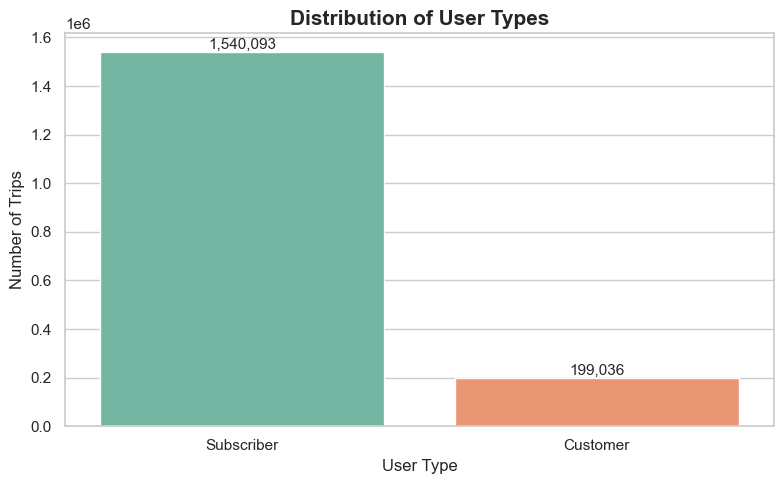

In [45]:
# ============================================
# User Type Distribution
# ============================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="user_type",
    palette="Set2"
)

plt.title("Distribution of User Types", fontsize=15, fontweight="bold")
plt.xlabel("User Type", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

# Add formatted labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11)

plt.tight_layout()
plt.show()

# 📊 Observation

The distribution shows that Subscribers account for the vast majority of bike trips, with approximately 1.54 million rides, while Customers contribute around 199 thousand rides. This indicates that the service is predominantly used by registered members rather than occasional users.

# 💼 Business Insight

The strong preference for subscription-based usage suggests that the bike-sharing system primarily serves regular commuters and frequent riders. This stable subscriber base is valuable for generating consistent revenue. To further expand the customer base, the company could introduce promotional offers or discounted membership plans aimed at encouraging occasional customers to become long-term subscribers.

## 2.Gender Distribution

Understanding the gender distribution of riders provides insights into the customer demographics of the bike-sharing service.

This analysis helps identify whether the service is equally used across different genders or if one group represents the majority of users. Such insights can support targeted marketing campaigns and initiatives to encourage broader participation.

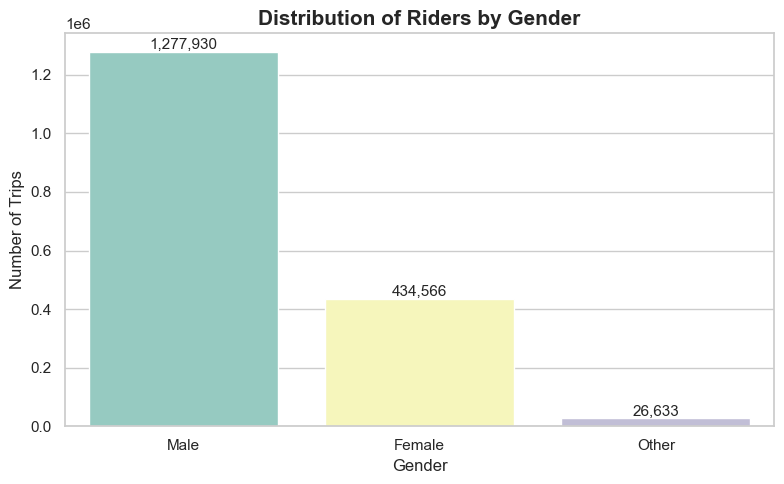

In [46]:
# ============================================
# Gender Distribution
# ============================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="member_gender",
    order=df_clean["member_gender"].value_counts().index,
    palette="Set3"
)

plt.title("Distribution of Riders by Gender", fontsize=15, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

# Add formatted labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11)

plt.tight_layout()
plt.show()

# 📊 Observation

The gender distribution shows that male riders account for the majority of bike trips, with 1,277,930 trips, followed by 434,566 trips by female riders. The "Other" gender category represents a very small proportion of the total trips, with 26,633 rides.

# 💼 Business Insight

The significant difference in ridership suggests that the bike-sharing service is predominantly used by male riders. This presents an opportunity to better understand the barriers that may limit participation among female riders. Improving cycling infrastructure, enhancing safety measures, and introducing targeted promotional campaigns could encourage greater adoption across a more diverse customer base.

## 3. Age Distribution

Age plays an important role in understanding customer demographics and riding behavior.

Analyzing the distribution of rider ages helps identify the primary user groups of the bike-sharing service. These insights can support targeted marketing strategies, membership plans, and service improvements designed for different age segments.

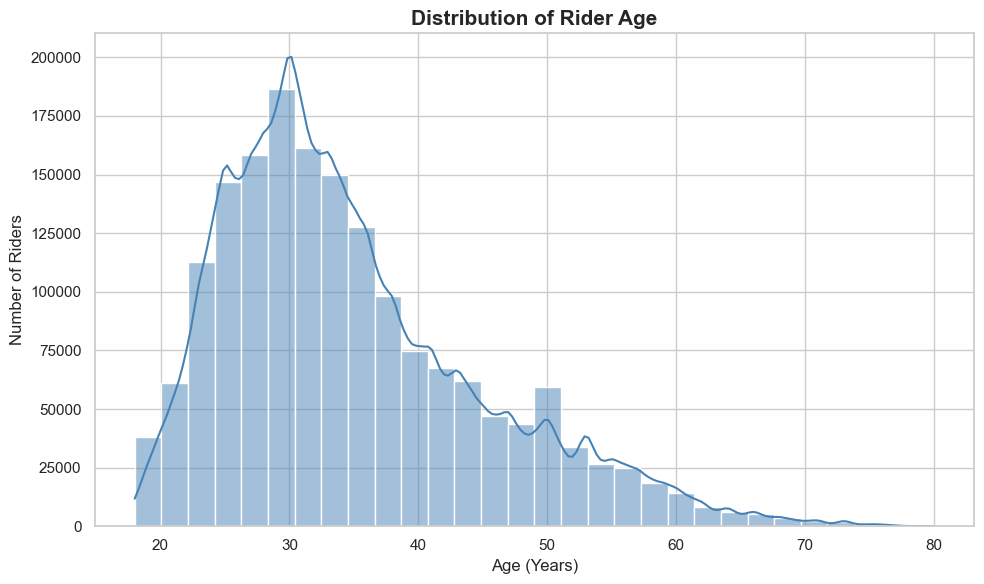

In [47]:
# ============================================
# Age Distribution
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_clean,
    x="age",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Rider Age", fontsize=15, fontweight="bold")
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Riders", fontsize=12)

plt.tight_layout()
plt.show()

# 📊 Observation

The age distribution is right-skewed, indicating that most riders are young adults. The highest concentration of riders falls between 25 and 35 years, with the peak occurring around 30 years of age. As age increases beyond 35, the number of riders gradually declines, while riders above 60 years represent only a small portion of the total user base.

# 💼 Business Insight

The bike-sharing service is primarily used by working-age adults, suggesting that commuting and daily travel are the main use cases. This indicates an opportunity to strengthen commuter-focused services, such as corporate membership plans, office partnerships, and peak-hour bike availability. To increase adoption among older adults, the company could introduce awareness campaigns, discounted senior memberships, or improve accessibility and safety features.

## 4. Age Group Distribution

While the age distribution provides a detailed view of rider ages, grouping riders into age categories makes the results easier to interpret from a business perspective.

This analysis helps identify the customer segments that contribute the most to bike-sharing usage and supports targeted marketing and service planning.

In [48]:
# ============================================
# Create Age Groups
# ============================================

age_bins = [18, 25, 35, 45, 55, 80]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-80"
]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

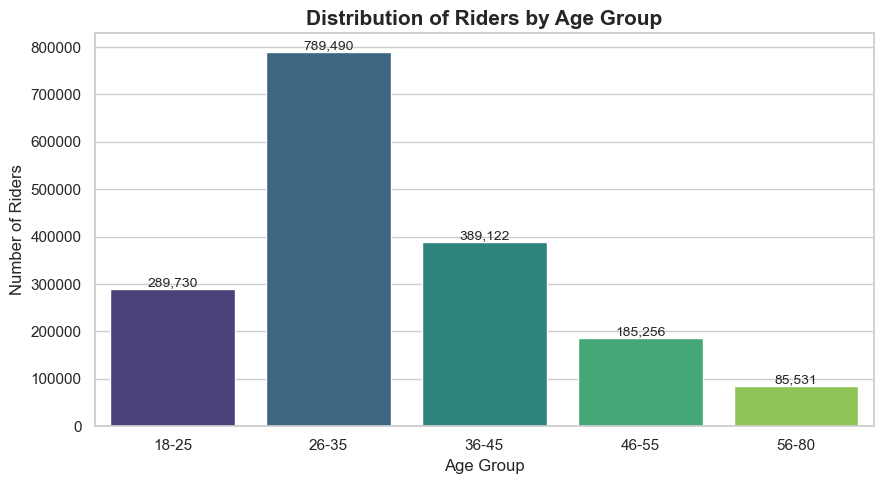

In [49]:
# ============================================
# Age Group Distribution
# ============================================

plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=df_clean,
    x="age_group",
    palette="viridis"
)

plt.title("Distribution of Riders by Age Group", fontsize=15, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Riders", fontsize=12)

# Add formatted labels
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10)

plt.tight_layout()
plt.show()

# Time-Based Analysis

Time-based analysis helps us understand how bike-sharing demand changes over different time periods.

By analyzing rides across months, weekdays, hours, and different times of the day, we can identify seasonal patterns, peak demand periods, and customer commuting behavior.

These insights can help optimize bike availability, station management, maintenance schedules, and promotional campaigns.

## 5. Monthly Ride Trends

Analyzing ride activity across different months helps identify seasonal variations in bike-sharing demand.

This analysis highlights periods of high and low usage, allowing the company to better plan bike availability, maintenance schedules, and seasonal marketing strategies.

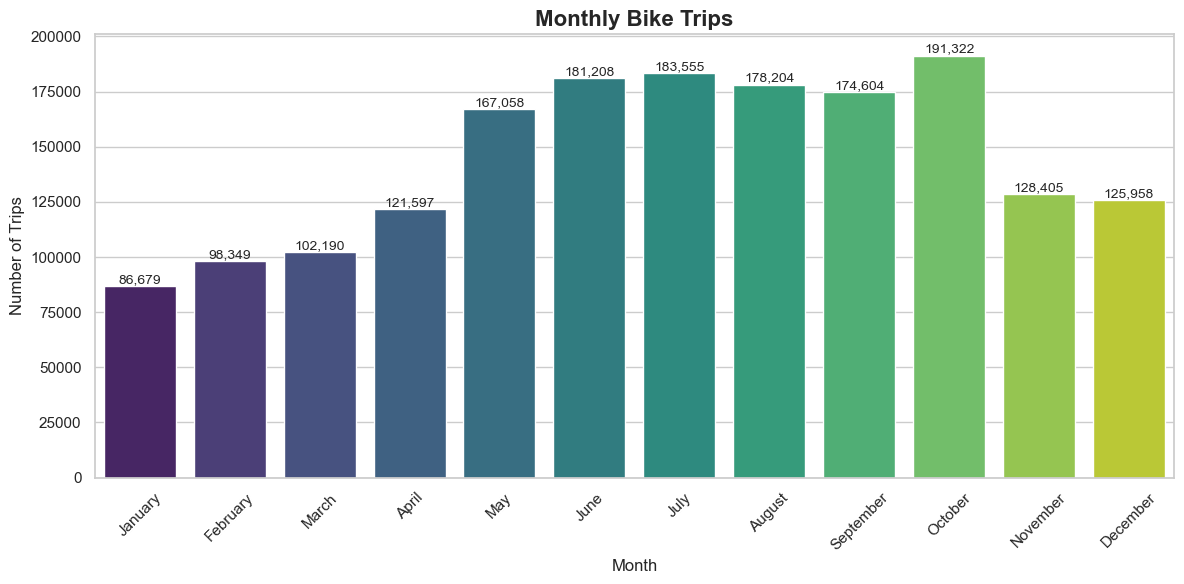

In [50]:
# ============================================
# Monthly Ride Trends
# ============================================

monthly_trips = (
    df_clean["month_name"]
    .value_counts()
    .reindex([
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ])
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=monthly_trips.index,
    y=monthly_trips.values,
    palette="viridis"
)

plt.title("Monthly Bike Trips", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)
plt.xticks(rotation=45)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Observation

Bike-sharing demand shows a clear seasonal trend throughout the year. The number of trips increases steadily from January (86,679 trips) to October (191,322 trips), making October the busiest month in the dataset. After October, ridership declines noticeably during November (128,405 trips) and December (125,958 trips), indicating lower demand towards the end of the year.

## 💼 Business Insight

The steady increase in ridership from winter to autumn suggests that weather and seasonal conditions significantly influence bike usage. During peak months, the company should ensure sufficient bike availability, increase maintenance capacity, and optimize bike distribution across high-demand stations. Conversely, the decline in November and December presents a good opportunity for preventive maintenance, fleet servicing, and promotional campaigns to encourage ridership during off-peak periods.

### 6. Weekly Ride Trends

Analyzing rides across the days of the week helps identify weekly usage patterns and understand customer behavior.

This analysis can reveal whether the bike-sharing service is primarily used for daily commuting or recreational purposes. It also helps in planning bike availability and operational resources throughout the week.

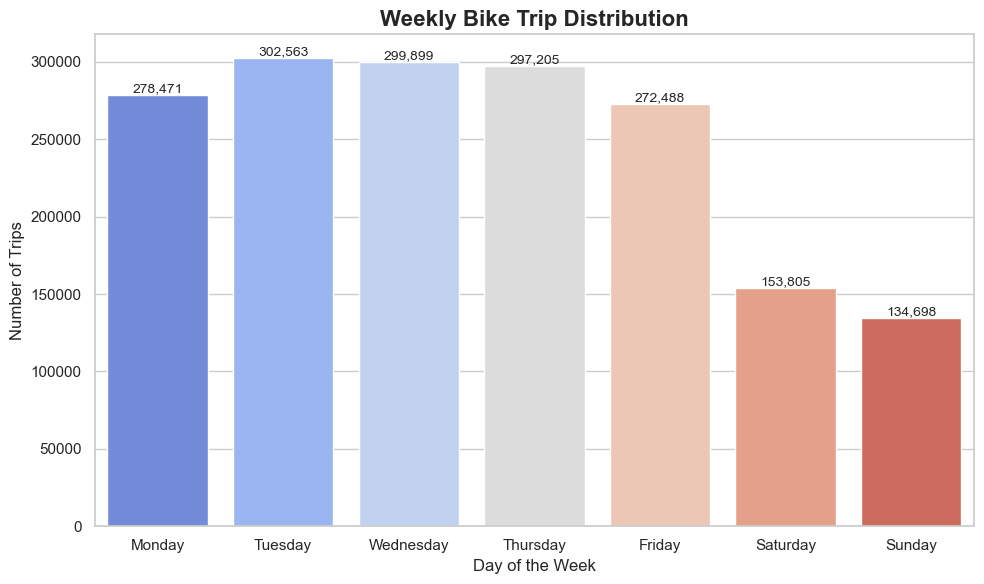

In [51]:
# ============================================
# Weekly Ride Trends
# ============================================

# Define the correct weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Count rides for each day
weekly_trips = (
    df_clean["day_name"]
    .value_counts()
    .reindex(weekday_order)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=weekly_trips.index,
    y=weekly_trips.values,
    palette="coolwarm"
)

plt.title("Weekly Bike Trip Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Observation

The weekly ride distribution shows that bike usage is highest during weekdays, with Tuesday (302,563 trips) recording the highest number of rides, closely followed by Wednesday (299,899 trips) and Thursday (297,205 trips). Ridership begins to decline on Friday (272,488 trips) and drops significantly over the weekend, with Saturday (153,805 trips) and Sunday (134,698 trips) recording the lowest trip counts.

## 💼 Business Insight

The significantly higher ridership during weekdays indicates that the bike-sharing service is primarily used for daily commuting rather than recreational purposes. The sharp decline in weekend usage suggests that most customers rely on the service for work or educational travel. To improve weekend ridership, the company could introduce discounted weekend passes, family packages, or partner with tourist attractions and recreational areas to encourage leisure usage.

## 7. Hourly Ride Trends

Analyzing ride activity by hour of the day helps identify peak usage periods and understand daily travel behavior.

This analysis reveals when customers are most likely to use the bike-sharing service, allowing the company to optimize bike availability, station capacity, and maintenance schedules during high-demand hours.

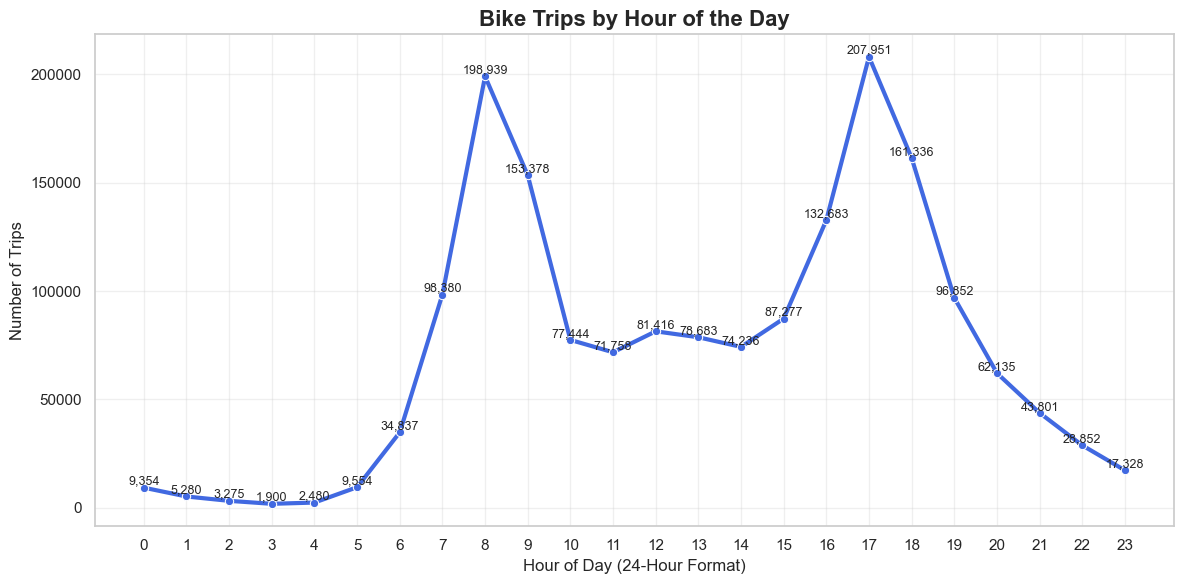

In [52]:
# ============================================
# Hourly Ride Trends
# ============================================

# Count trips by hour
hourly_trips = (
    df_clean["ride_hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    x=hourly_trips.index,
    y=hourly_trips.values,
    marker="o",
    linewidth=3,
    color="royalblue"
)

plt.title("Bike Trips by Hour of the Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day (24-Hour Format)", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

plt.xticks(range(0,24))

# Add value labels
for x, y in zip(hourly_trips.index, hourly_trips.values):
    plt.text(x, y+1500, f"{y:,}", ha='center', fontsize=9)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Observation

The hourly ride trend reveals a clear bimodal distribution, with two distinct peaks during the day. The morning peak occurs at 8:00 AM, recording 198,939 trips, while the evening peak occurs at 5:00 PM (17:00) with 207,951 trips, making it the busiest hour of the day. Ride activity remains very low during the late-night and early-morning hours (12:00 AM–5:00 AM), gradually increases after 6:00 AM, and declines steadily after the evening peak.

## 💼 Business Insight

The presence of two pronounced peak periods indicates that the bike-sharing system is primarily used for daily commuting. Riders use the service to travel to work or educational institutions in the morning and return home in the evening. To maintain service quality, the company should ensure that bikes are sufficiently distributed across high-demand stations before the morning and evening rush hours. Additionally, maintenance activities should be scheduled during low-demand periods, such as late night or early morning, to minimize disruptions.

### 8.  Weekend vs Weekday Analysis

Comparing weekday and weekend ridership helps determine whether the bike-sharing service is primarily used for commuting or recreational purposes.

Understanding this pattern enables the company to optimize bike allocation, staffing, and promotional strategies for different periods of the week.

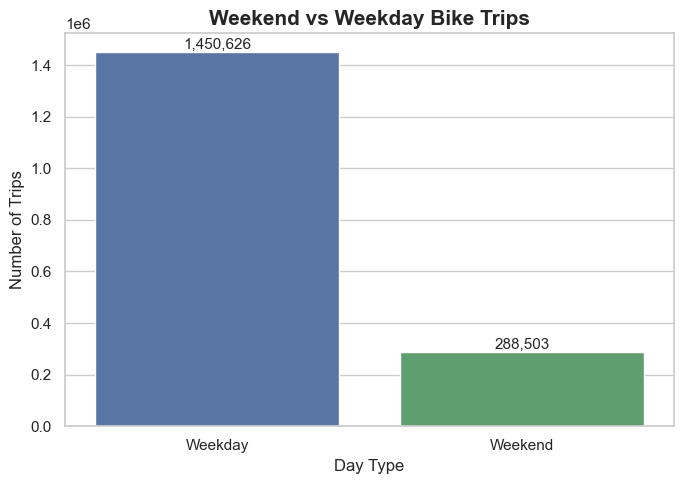

In [53]:
# ============================================
# Weekend vs Weekday Analysis
# ============================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df_clean,
    x="day_type",
    palette=["#4C72B0", "#55A868"]
)

plt.title("Weekend vs Weekday Bike Trips", fontsize=15, fontweight="bold")
plt.xlabel("Day Type", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

# Add formatted labels
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=11)

plt.tight_layout()
plt.show()

## 📊 Observation

The comparison between weekday and weekend trips shows a significant difference in bike usage. Weekdays account for approximately 1,450,626 trips, while weekends record only 288,503 trips. This indicates that the majority of bike trips occur during the working week, with weekday ridership being nearly five times higher than weekend ridership.

## 💼 Business Insight

The substantial gap between weekday and weekend usage confirms that the bike-sharing system is primarily used for daily commuting rather than recreational travel. This suggests that bike availability, station capacity, and maintenance schedules should be prioritized during weekdays, particularly around business districts and transit hubs. To increase weekend demand, the company could introduce discounted weekend passes, tourism partnerships, family ride packages, or recreational cycling events.

### 9. Bike Trips by Time of Day

While hourly analysis provides detailed information, grouping rides into broader time periods makes the results easier to interpret.

In this analysis, bike trips are categorized into four periods:
- Morning
- Afternoon
- Evening
- Night

This helps identify when the bike-sharing service experiences the highest demand throughout the day.

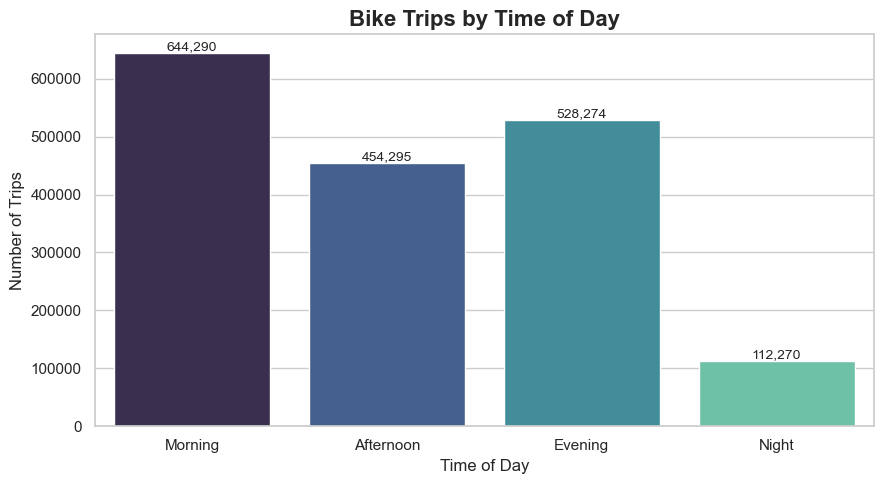

In [54]:
# ============================================
# Time of Day Distribution
# ============================================

plt.figure(figsize=(9,5))

# Define logical order
time_order = ["Morning", "Afternoon", "Evening", "Night"]

ax = sns.countplot(
    data=df_clean,
    x="time_of_day",
    order=time_order,
    palette="mako"
)

plt.title("Bike Trips by Time of Day", fontsize=16, fontweight="bold")
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Observation

The distribution of bike trips across different times of the day shows that Morning records the highest number of trips with 644,290 rides, followed by Evening with 528,274 rides. Afternoon accounts for 454,295 trips, while Night has the lowest usage with only 112,270 rides. This pattern indicates that bike usage is concentrated during standard commuting hours, with significantly lower activity during the night.

## 💼 Business Insight

The high demand during the morning and evening periods reflects the importance of the bike-sharing service for daily commuting. To improve customer experience, the company should prioritize bike availability and station capacity during these peak periods. Since night-time demand is relatively low, maintenance, battery charging (for e-bikes), and bike redistribution can be scheduled during these hours to minimize disruptions.

## Trip Analysis

Trip analysis focuses on understanding the characteristics of individual bike rides.

In this section, we examine trip duration and compare riding behavior across different customer segments, including user types, gender, and age groups. These insights help identify how different users interact with the bike-sharing system and support decisions related to pricing, memberships, and service planning.

## 10. Trip Duration Distribution

Trip duration is one of the most important indicators of customer behavior.

Analyzing the distribution of ride durations helps us understand how long customers typically use the bikes and identify whether most trips are short, medium, or long in duration. It also helps detect any unusually long rides that may require further investigation.

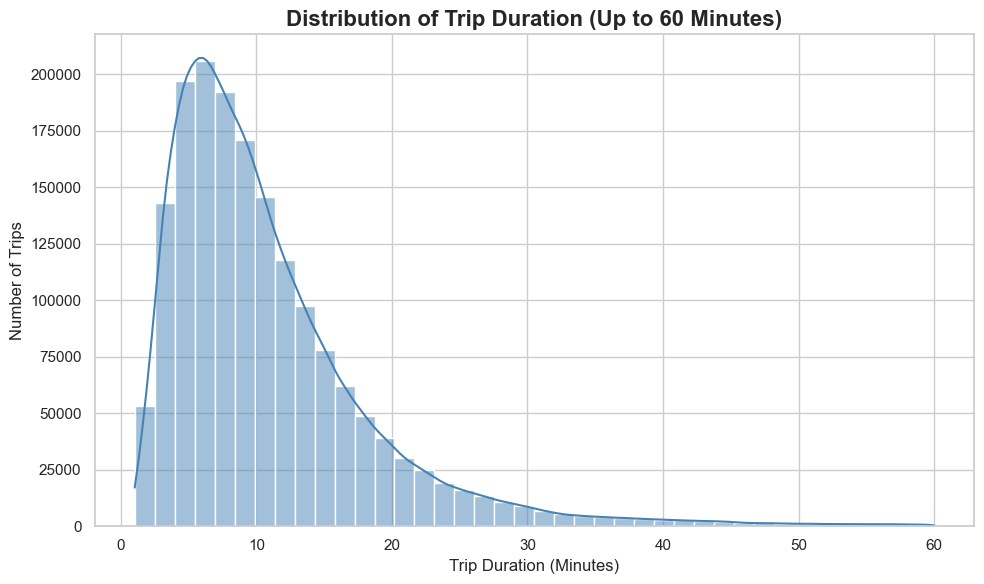

In [55]:
# ============================================
# Trip Duration Distribution (<= 60 Minutes)
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_clean[df_clean["trip_duration_min"] <= 60],
    x="trip_duration_min",
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Trip Duration (Up to 60 Minutes)",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Trip Duration (Minutes)", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

plt.tight_layout()
plt.show()

## 📊 Observation

The trip duration distribution is positively (right) skewed, indicating that most bike trips are relatively short. The highest concentration of rides occurs between 5 and 10 minutes, with the peak around 6–8 minutes. As trip duration increases beyond 15–20 minutes, the number of rides decreases steadily, while trips longer than 40 minutes are relatively uncommon.

## 💼 Business Insight

The dominance of short-duration trips suggests that the Ford GoBike system is primarily used for short-distance urban travel and daily commuting rather than extended recreational rides. This indicates that customers value quick, convenient transportation for first-mile and last-mile connectivity. To maintain service efficiency, the company should focus on ensuring high bike availability and rapid bike turnover at busy stations rather than supporting long-duration rentals.

## 11. Trip Duration by User Type

Different membership types often reflect different usage patterns.

By comparing trip durations between Subscribers and Customers, we can understand whether regular members primarily use the service for commuting, while casual customers use it for longer recreational rides.

This comparison provides valuable insights into customer behavior and supports decisions related to membership plans and pricing strategies.

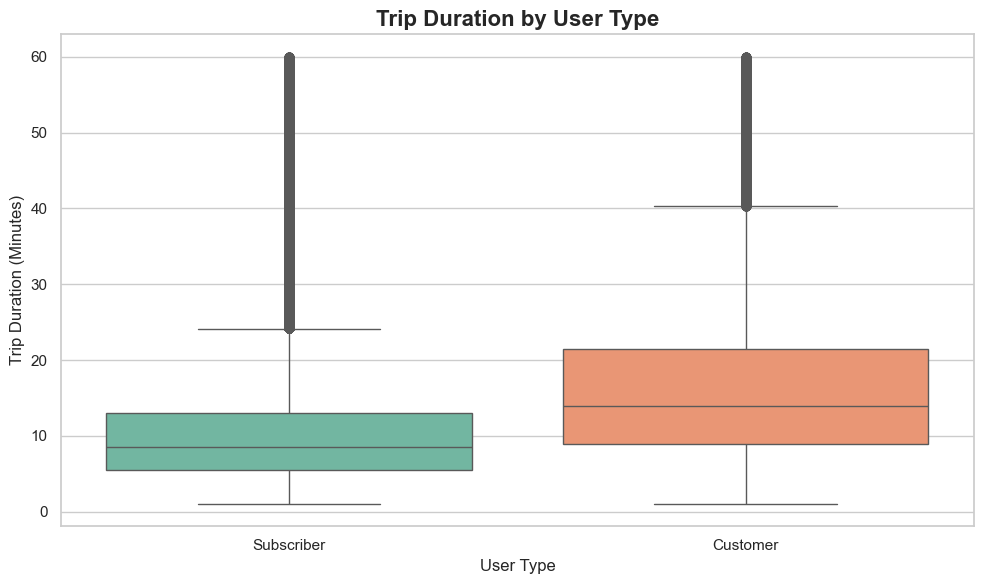

In [56]:
# ============================================
# Trip Duration by User Type
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean[df_clean["trip_duration_min"] <= 60],
    x="user_type",
    y="trip_duration_min",
    palette="Set2"
)

plt.title("Trip Duration by User Type", fontsize=16, fontweight="bold")
plt.xlabel("User Type", fontsize=12)
plt.ylabel("Trip Duration (Minutes)", fontsize=12)

plt.tight_layout()
plt.show()

## 📊 Observation

The box plot reveals a noticeable difference in trip duration between Subscribers and Customers. Subscribers have a lower median trip duration of approximately 8 minutes and a relatively narrow interquartile range, indicating that most of their rides are short and consistent. In contrast, Customers have a higher median trip duration of around 14 minutes and a much wider spread, suggesting that they generally take longer and more variable trips. Although both groups contain a few longer rides (outliers), Customers exhibit greater variation in trip duration than Subscribers.

## 💼 Business Insight

The shorter and more consistent ride durations among Subscribers indicate that they primarily use the bike-sharing service for daily commuting and routine travel. On the other hand, Customers tend to use the service for longer recreational or occasional trips, which explains the higher median duration and wider distribution. These behavioral differences suggest that the company should continue offering commuter-focused membership plans for Subscribers while introducing flexible hourly packages, tourist passes, or leisure-oriented promotions to better serve casual Customers.

## Trip Duration by Gender

Comparing trip duration across different genders helps identify variations in riding behavior among customer groups.

This analysis provides insights into whether certain demographic groups tend to take longer or shorter trips, supporting customer segmentation and targeted service improvements.

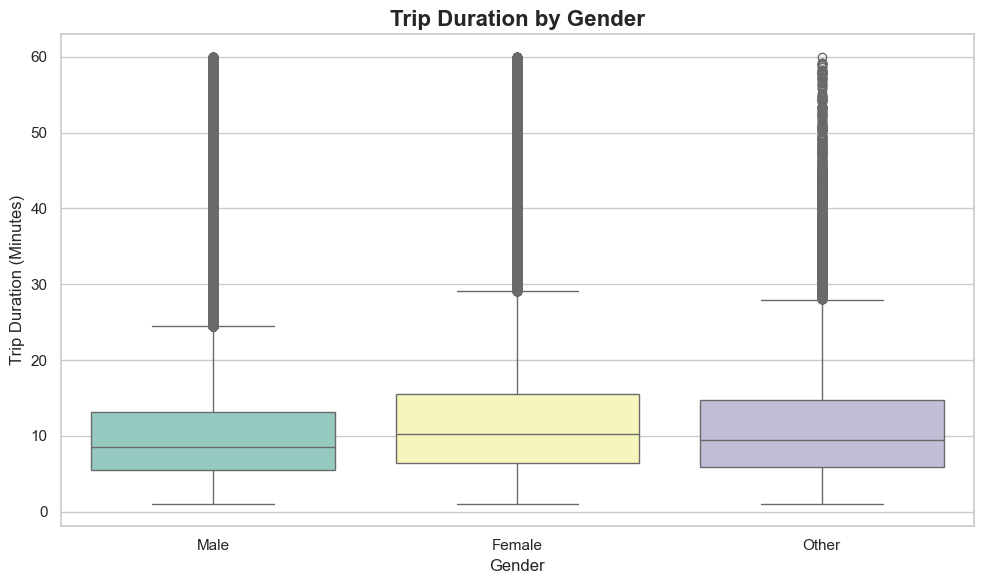

In [57]:
# ============================================
# Trip Duration by Gender
# ============================================

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=df_clean[df_clean["trip_duration_min"] <= 60],
    x="member_gender",
    y="trip_duration_min",
    palette="Set3"
)

plt.title("Trip Duration by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Trip Duration (Minutes)", fontsize=12)

plt.tight_layout()
plt.show()

### 📊 Observation

The box plot shows that trip durations are fairly similar across all gender groups, with only slight differences in their distributions. Female riders have a slightly higher median trip duration than Male riders, indicating that they tend to take marginally longer trips on average. The "Other" category also shows a comparable distribution, although it contains significantly fewer observations. All three groups exhibit several long-duration outliers, suggesting that a small number of riders, regardless of gender, occasionally take extended trips.

### 💼 Business Insight

The relatively similar trip duration patterns across genders suggest that gender has only a limited influence on riding behavior. Instead, factors such as membership type, commuting purpose, trip distance, or time of travel are likely to have a greater impact on ride duration. This indicates that operational decisions and marketing strategies should focus more on customer usage patterns rather than gender-specific differences.

### Trip Duration by Age Group

Age can influence how customers use the bike-sharing service.

Comparing trip duration across different age groups helps identify whether younger or older riders tend to take longer trips. These insights can support customer segmentation, targeted promotions, and service planning.

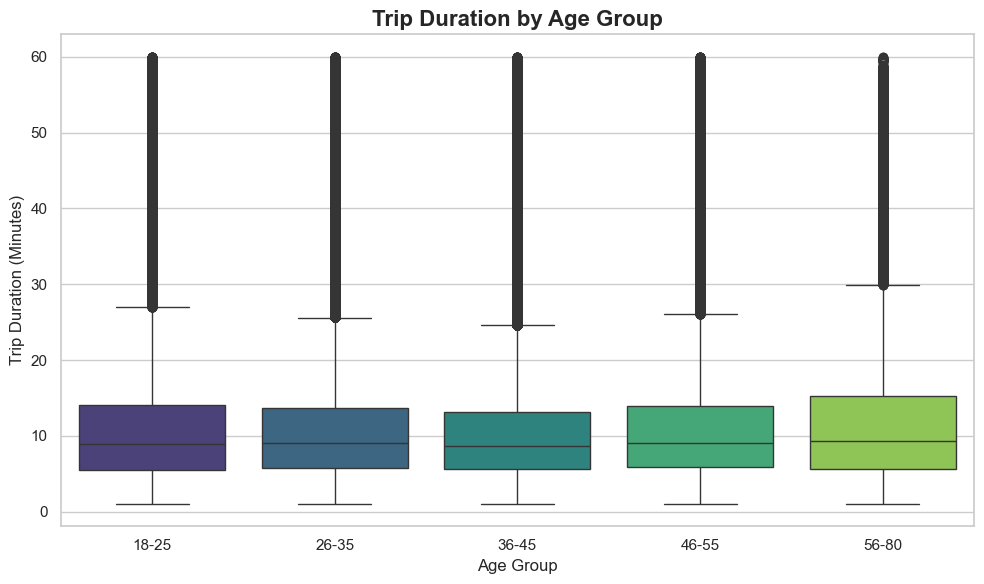

In [58]:
# ============================================
# Trip Duration by Age Group
# ============================================

plt.figure(figsize=(10,6))

age_order = ["18-25", "26-35", "36-45", "46-55", "56-80"]

ax = sns.boxplot(
    data=df_clean[df_clean["trip_duration_min"] <= 60],
    x="age_group",
    y="trip_duration_min",
    order=age_order,
    palette="viridis"
)

plt.title("Trip Duration by Age Group", fontsize=16, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Trip Duration (Minutes)", fontsize=12)

plt.tight_layout()
plt.show()

## 📊 Observation

The box plot indicates that trip durations remain relatively consistent across all age groups, with median ride durations generally ranging between 8 and 10 minutes. The 56–80 age group exhibits a slightly wider distribution and a higher upper quartile, suggesting that some older riders tend to take longer trips. In contrast, the 18–25, 26–35, and 36–45 age groups display more compact distributions, indicating shorter and more consistent ride durations. Long-duration outliers are present across all age groups.

## 💼 Business Insight

The similarity in median trip durations across age groups suggests that age has only a limited impact on how long customers use the bike-sharing service. Regardless of age, most users appear to rely on the service for short-distance urban travel. The slightly longer rides among older users may indicate greater use for leisure or relaxed travel rather than daily commuting. These findings suggest that service improvements should prioritize overall rider convenience rather than age-specific operational strategies.

##  Station Analysis

Station analysis focuses on understanding where customers begin and end their bike trips.

By identifying the busiest stations and the most frequently traveled routes, we can better understand travel demand, optimize bike allocation, improve station capacity, and support operational planning.

The insights from this section can help reduce bike shortages at high-demand stations and improve the overall efficiency of the bike-sharing system.

## Top 10 Start Stations

This analysis identifies the stations where the highest number of bike trips begin.

Knowing the busiest start stations helps the bike-sharing company allocate bikes more efficiently and ensure sufficient availability during peak demand periods.

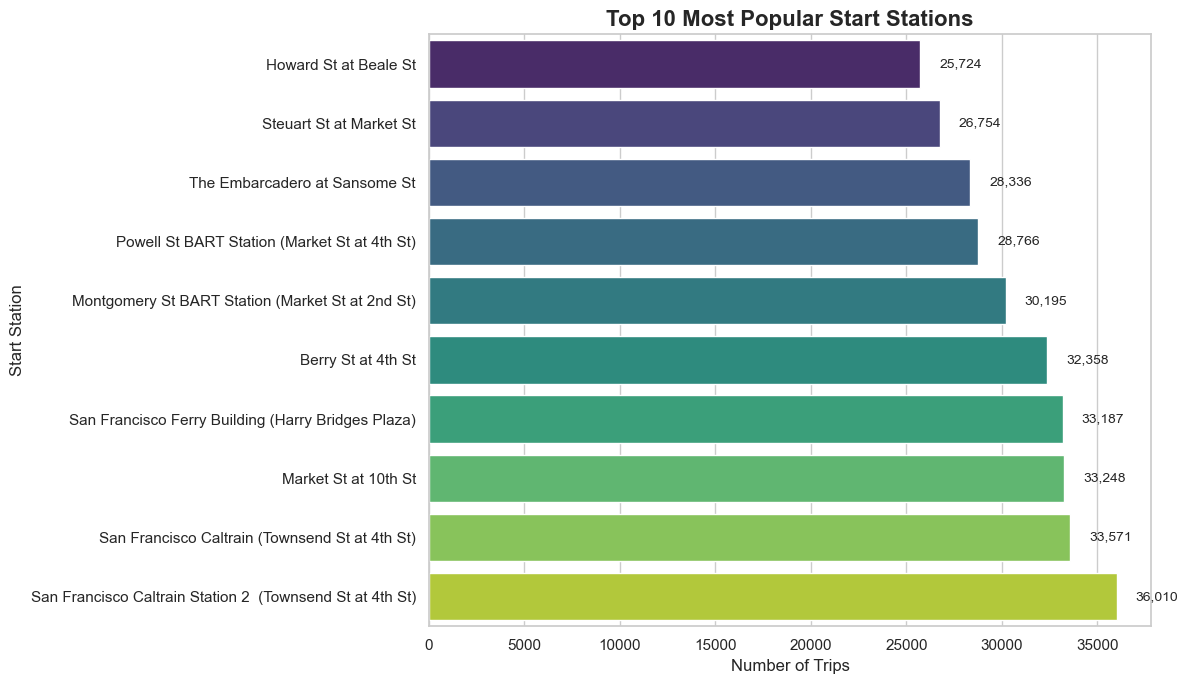

In [59]:
# ============================================
# Top 10 Start Stations
# ============================================

top_start = (
    df_clean["start_station_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_start.values,
    y=top_start.index,
    palette="viridis"
)

plt.title("Top 10 Most Popular Start Stations",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Trips", fontsize=12)
plt.ylabel("Start Station", fontsize=12)

# Add labels
for i, value in enumerate(top_start.values):
    plt.text(value + 1000,
             i,
             f"{value:,}",
             va="center",
             fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Observation

The analysis shows that San Francisco Caltrain Station 2 (Townsend St at 4th St) is the busiest start station, recording 36,010 trips, followed by San Francisco Caltrain (Townsend St at 4th St) with 33,571 trips and Market St at 10th St with 33,248 trips. Most of the top-performing stations are located near major public transportation hubs, business districts, and commuter corridors, indicating that riders frequently begin their journeys from high-traffic urban locations.

## 💼 Business Insight

The concentration of trips at a few major stations suggests that these locations act as key transportation hubs within the bike-sharing network. To maintain service reliability, the company should prioritize these stations for bike redistribution, regular maintenance, and capacity expansion during peak hours. Integrating bike-sharing services more closely with nearby public transit stations could further improve first-mile and last-mile connectivity for commuters.

## Top 10 End Stations

This analysis identifies the stations where the highest number of bike trips end.

Understanding destination patterns helps the bike-sharing company identify high-demand arrival locations, optimize docking capacity, and improve bike redistribution strategies. These insights are valuable for ensuring that stations can accommodate incoming bikes during peak travel periods.

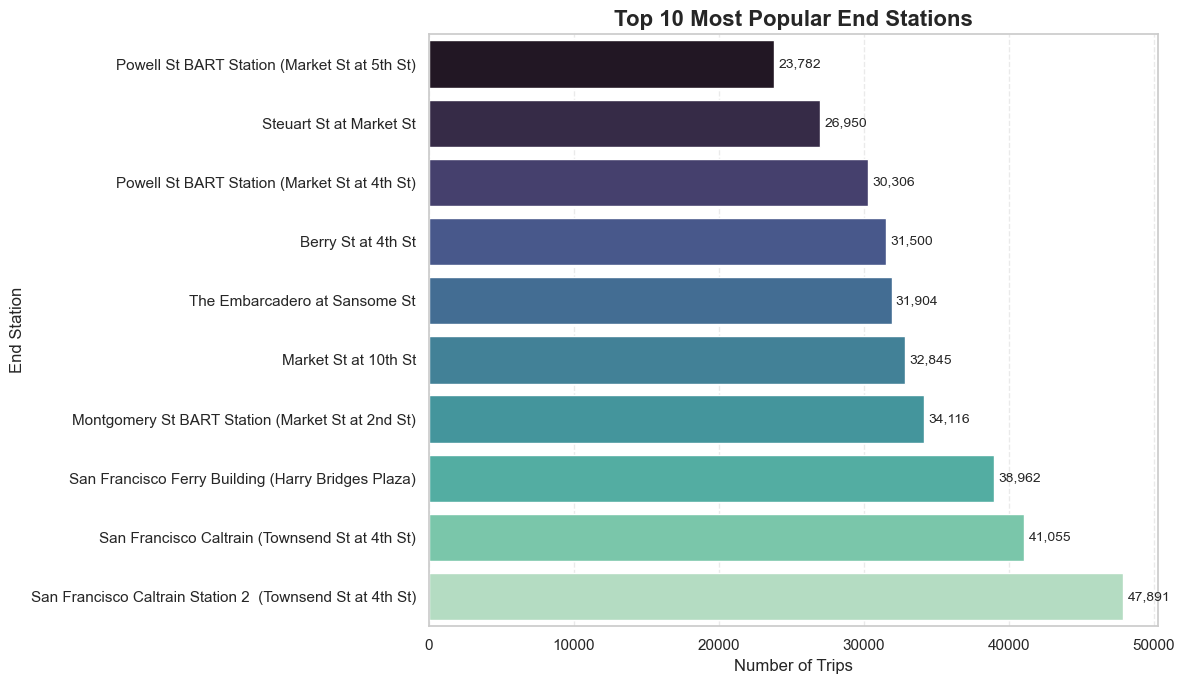

In [60]:
# ============================================
# Top 10 End Stations
# ============================================

top_end = (
    df_clean["end_station_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_end.values,
    y=top_end.index,
    palette="mako"
)

plt.title("Top 10 Most Popular End Stations",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Trips", fontsize=12)
plt.ylabel("End Station", fontsize=12)

# Add value labels
for i, value in enumerate(top_end.values):
    plt.text(value + 300,
             i,
             f"{value:,}",
             va="center",
             fontsize=10)

# Add grid for readability
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 📊 Observation

The analysis reveals that San Francisco Caltrain Station 2 (Townsend St at 4th St) is the busiest destination station, recording 47,891 trip arrivals, followed by San Francisco Caltrain (Townsend St at 4th St) with 41,055 arrivals and San Francisco Ferry Building (Harry Bridges Plaza) with 38,962 arrivals. Most of the busiest end stations are located near major transit hubs and commercial areas, indicating that riders commonly use the bike-sharing service to complete the final leg of their commute.

## 💼 Business Insight

The high concentration of trip arrivals at transit-oriented stations suggests that these locations play a critical role in the city's transportation network. To prevent docking shortages during peak hours, the company should expand docking capacity, monitor station occupancy in real time, and implement proactive bike redistribution strategies. Integrating bike-sharing operations with public transportation schedules can further improve first-mile and last-mile connectivity.

## Top 10 Most Popular Routes

A route represents the journey between a start station and an end station.

Analyzing the most frequently traveled routes helps identify major travel corridors within the bike-sharing network. These insights support route optimization, bike redistribution, infrastructure planning, and operational decision-making by highlighting the areas with the highest travel demand.

In [61]:
# ============================================
# Create Route Column
# ============================================

df_clean["route"] = (
    df_clean["start_station_name"] +
    " → " +
    df_clean["end_station_name"]
)

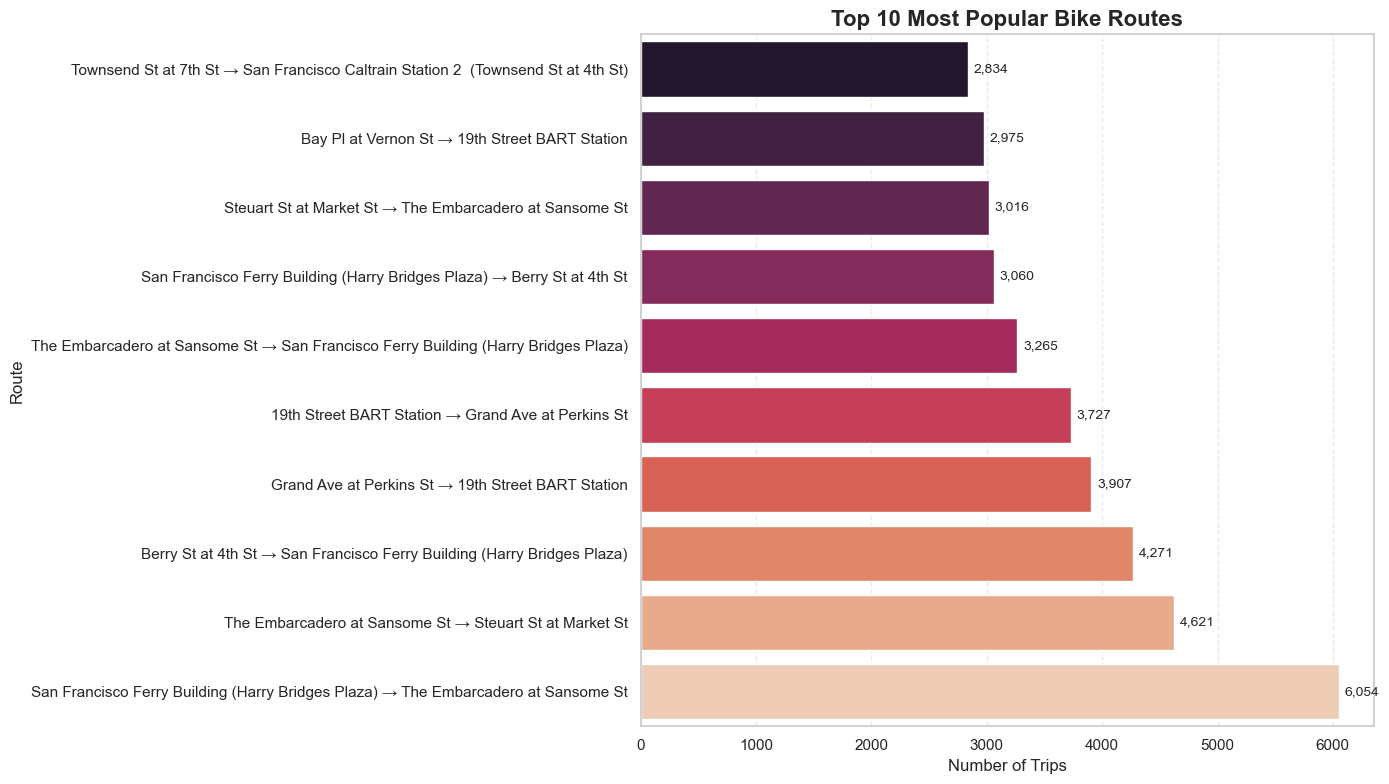

In [62]:
# ============================================
# Top 10 Most Popular Routes
# ============================================

top_routes = (
    df_clean["route"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(14,8))

ax = sns.barplot(
    x=top_routes.values,
    y=top_routes.index,
    palette="rocket"
)

plt.title(
    "Top 10 Most Popular Bike Routes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Trips", fontsize=12)
plt.ylabel("Route", fontsize=12)

# Add labels
for i, value in enumerate(top_routes.values):
    plt.text(
        value + 50,
        i,
        f"{value:,}",
        va="center",
        fontsize=10
    )

# Add grid
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 📊 Observation

The route analysis shows that the most frequently traveled route is San Francisco Ferry Building (Harry Bridges Plaza) → The Embarcadero at Sansome St, with 6,054 trips, making it the busiest travel corridor in the bike-sharing network. Several of the top routes connect major transit stations, business districts, and waterfront locations, indicating strong commuter movement between key commercial and transportation hubs. Additionally, many popular routes appear in both directions, suggesting regular two-way travel between these locations.

## 💼 Business Insight

The high demand along these travel corridors highlights the need for efficient bike redistribution and sufficient station capacity at both origin and destination stations. Since many of the busiest routes connect transportation hubs and employment centers, the company should prioritize these corridors for bike availability during peak commuting hours. The popularity of two-way routes also suggests balanced travel demand, making these locations ideal candidates for infrastructure improvements such as expanded docking stations or dedicated cycling lanes.

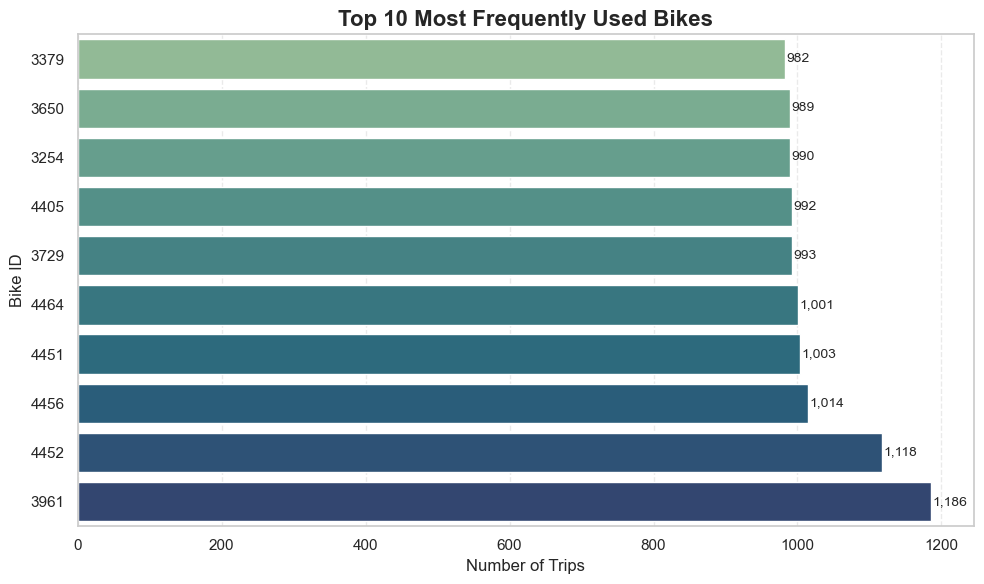

In [63]:
# ============================================
# Top 10 Most Used Bikes
# ============================================

top_bikes = (
    df_clean["bike_id"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_bikes.values,
    y=top_bikes.index.astype(str),
    palette="crest"
)

plt.title("Top 10 Most Frequently Used Bikes",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Trips", fontsize=12)
plt.ylabel("Bike ID", fontsize=12)

# Add labels
for i, value in enumerate(top_bikes.values):
    plt.text(value + 2,
             i,
             f"{value:,}",
             va="center",
             fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 📊 Observation

The analysis shows that Bike ID 3961 is the most frequently used bike, completing 1,186 trips, followed by Bike ID 4452 with 1,118 trips and Bike ID 4456 with 1,014 trips. The difference in trip counts among the top 10 bikes is relatively small, ranging from 982 to 1,186 trips, suggesting that the most active bikes are utilized at similar levels.

## 💼 Business Insight

The relatively balanced trip counts among the most frequently used bikes indicate that the bike-sharing system distributes demand reasonably well across its fleet. However, bikes with consistently higher usage should be monitored more closely for preventive maintenance and component replacement to ensure safety and minimize unexpected downtime. A predictive maintenance strategy based on ride frequency could further improve fleet reliability and extend bike lifespan.

## Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables.

A correlation heatmap provides a visual summary of these relationships, helping identify features that move together and supporting further exploratory analysis.

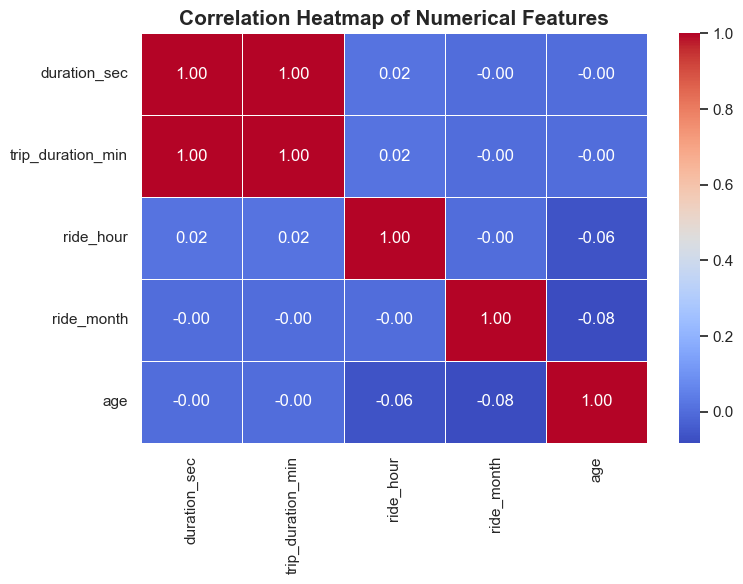

In [64]:
# ============================================
# Correlation Heatmap
# ============================================

# Select numerical columns
corr_data = df_clean[
    [
        "duration_sec",
        "trip_duration_min",
        "ride_hour",
        "ride_month",
        "age"
    ]
]

# Compute correlation matrix
corr_matrix = corr_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 📊 Observation

The correlation heatmap indicates that duration_sec and trip_duration_min have a perfect positive correlation (1.00) because both variables represent trip duration in different units. Apart from this expected relationship, all other numerical variables exhibit very weak correlations, with coefficients close to zero. This suggests that factors such as ride hour, ride month, and rider age have little linear relationship with trip duration or with each other.

### 💼 Business Insight

The weak correlations imply that bike-sharing usage is influenced by multiple independent factors rather than a single numerical variable. Customer behavior appears to depend more on contextual factors such as membership type, commuting purpose, station location, and time of travel than on age or month alone. This highlights the importance of combining demographic, temporal, and spatial analyses to fully understand rider behavior.

# Business Recommendations

Based on the exploratory data analysis, the following recommendations can help improve the efficiency, customer experience, and overall performance of the Ford GoBike bike-sharing system.

### 1. Improve Bike Availability During Peak Hours
The highest demand occurs around **8:00 AM** and **5:00 PM**, indicating strong commuter usage. Additional bikes should be deployed before these peak periods to reduce shortages.

### 2. Prioritize High-Demand Stations
Stations such as **San Francisco Caltrain Station 2** and **San Francisco Ferry Building** consistently record the highest trip volumes. These locations should receive priority for bike redistribution, maintenance, and possible station expansion.

### 3. Introduce Weekend Promotions
Weekend ridership is significantly lower than weekday usage. Offering discounted weekend passes, family packages, or tourist promotions could encourage more recreational trips.

### 4. Expand Integration with Public Transport
Many of the busiest stations are located near major transit hubs. Strengthening partnerships with public transportation services can improve first-mile and last-mile connectivity.

### 5. Implement Predictive Maintenance
The most frequently used bikes should be monitored using ride-frequency data to schedule preventive maintenance before mechanical issues occur.

### 6. Target Casual Customers
Customers generally take longer trips than Subscribers. Introducing attractive membership plans and promotional offers may encourage occasional users to become long-term subscribers.

### 7. Optimize Bike Redistribution
Popular travel corridors should be monitored continuously to ensure that bikes are redistributed efficiently between high-demand stations, reducing shortages during peak commuting hours.

### 8. Use Data-Driven Operational Planning
Regular analysis of ridership trends, station demand, and travel patterns should guide decisions related to fleet expansion, staffing, and infrastructure improvements.